In [1]:
from reaction_diffusion_model import *
from transfer import *
from helper import *

import pickle
import numpy as np
from matplotlib import pyplot as plt

import time as time
from tqdm.auto import tqdm

import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter

c:\Users\ryqhe\Desktop\iclr2026workshop\Cheby-PINNs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the trained Model

In [2]:
k= 16
model = Multihead_model(k=k, act = nn.functional.silu, bias=True)

In [3]:
path = 'Reaction_diffusion_16head_model_trig.pickle'
with open(path, 'rb') as f:
	model = pickle.load(f)

In [4]:
model

Multihead_model(
  (linear1): Linear(in_features=2, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=128, bias=True)
  (linear3): Linear(in_features=128, out_features=256, bias=True)
  (linear4): Linear(in_features=256, out_features=256, bias=True)
  (linear5): Linear(in_features=256, out_features=512, bias=True)
  (final_layers): ModuleList(
    (0-15): 16 x Linear(in_features=256, out_features=1, bias=True)
  )
)

## Load or Compute the hidden representation H

In [5]:
x, t, interior_tensor = generate_interior_tensor(I=60, require_grad = False)
x_boundary, t_boundary, boundary_tensor = generate_boundary_tensor(B=200, require_grad=False, method='equally-spaced')

bias=True
H_dict = compute_H_dict(model, I=60, B=200, bias=bias)

Differentiating H w.r.t. x now...
Finished computing Hx.
Differentiating H w.r.t. t now...
Finished computing Ht
Differentiating H_b w.r.t. x now...
Finished computing Hx_b.
Differentiating H_b w.r.t. t now...
Finished computing Ht_b


In [6]:
import pickle
path = 'Reaction_diffusion_16head_H_dict_trig.pickle'
file = open(path, 'wb')
pickle.dump(H_dict, file)
file.close()

In [7]:
import pickle
path = 'Reaction_diffusion_16head_H_dict_trig.pickle'
file = open(path, 'rb')
H_dict = pickle.load(file)
file.close()

In [8]:
M, Minv = compute_M(H_dict)
print(M.shape)
print("Condition Number: ", np.linalg.cond(M))

(257, 257)
Condition Number:  10682094185.943739


In [9]:
_, H  = model(X_grid)
H = H.detach().numpy()
H = H.reshape(2*H.shape[0], -1)
bias = True
if bias: H = np.hstack((H, np.ones((H.shape[0], 1))))

## Test on the 16 systems used to train the model

In [10]:
k1 = 2
K2 = np.linspace(1, 2, 8)
A_list = [0.5, -0.5]; b = 0.5; k=16

truth_functions = []; Forcing_functions = []

for k2 in K2:
	for A in A_list:
		truth_functions.append(truth_decorator_trig(A, k1, k2, b=b))
		Forcing_functions.append(forcing_decorator_trig(A, k1, k2, D=1))

truth_solution = [truth_functions[i](X_grid[:,0], X_grid[:,1]).cpu().detach().numpy().reshape(round(X_grid.shape[0]**.5), -1) for i in range(k)]

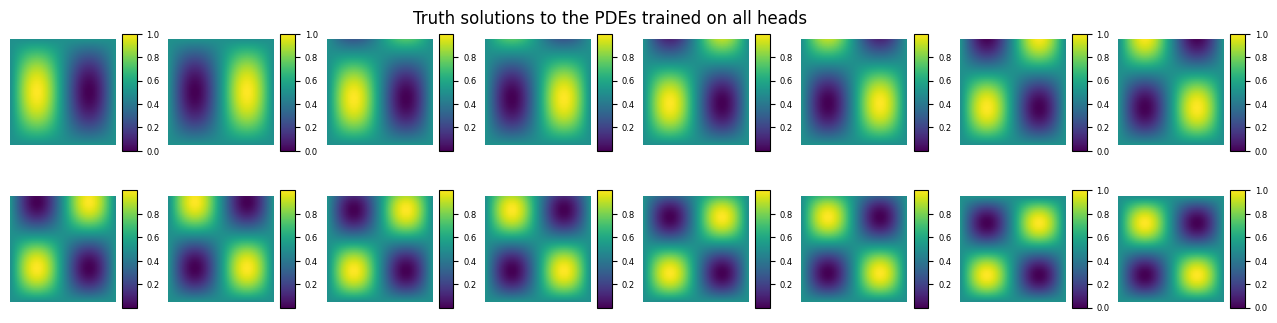

In [11]:
plot_solutions16(truth_solution, title="Truth solutions to the PDEs trained on all heads", savfig = "solutions_train_16heads.png")

In [12]:
truth_solution = np.array(truth_solution)

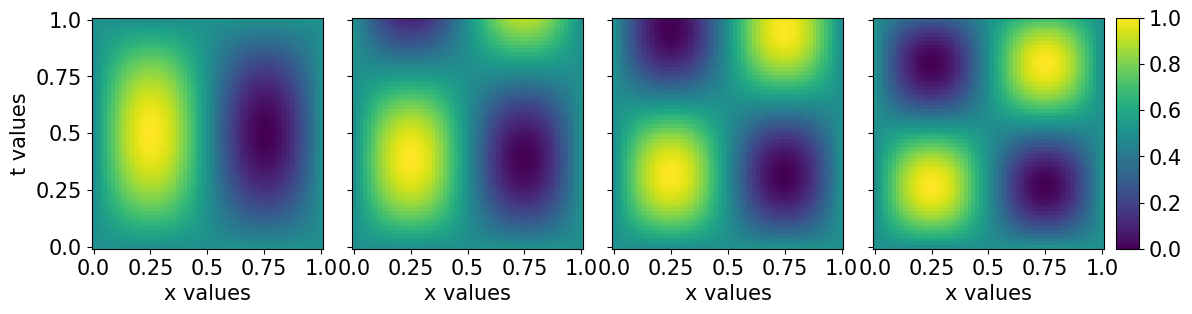

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
cmap = plt.get_cmap('viridis')
global_min = min([truth.min() for truth in truth_solution[[0, 4, 8, 12]]])
global_max = max([truth.max() for truth in truth_solution[[0, 4, 8, 12]]])
normalizer = Normalize(global_min, global_max)
im = cm.ScalarMappable(norm=normalizer)

for i in range(4):
    ax[i].imshow(truth_solution[4*i][::-1, :], cmap=cmap, norm=normalizer)
    ax[i].set_xlabel("x values", fontsize=15)
    ax[i].set_xticks(np.linspace(0, 60, 5), np.linspace(0, 1, 5), fontsize=15)
ax[0].set_ylabel('t values', fontsize=15)
ax[0].set_yticks(np.linspace(0, 60, 5), np.linspace(1, 0, 5), fontsize=15)
plt.subplots_adjust(wspace=0.0)

cbar = fig.colorbar(im, ax=ax.ravel().tolist(), pad=0.01, aspect=10)
cbar.ax.tick_params(labelsize=15)
plt.savefig('4_heads_Reaction_Diffusion.png', dpi=500,  bbox_inches='tight')

Relative Erorr:  0.0014850944185055886
Mean Loss over all Heads:  3.18679111652538e-05


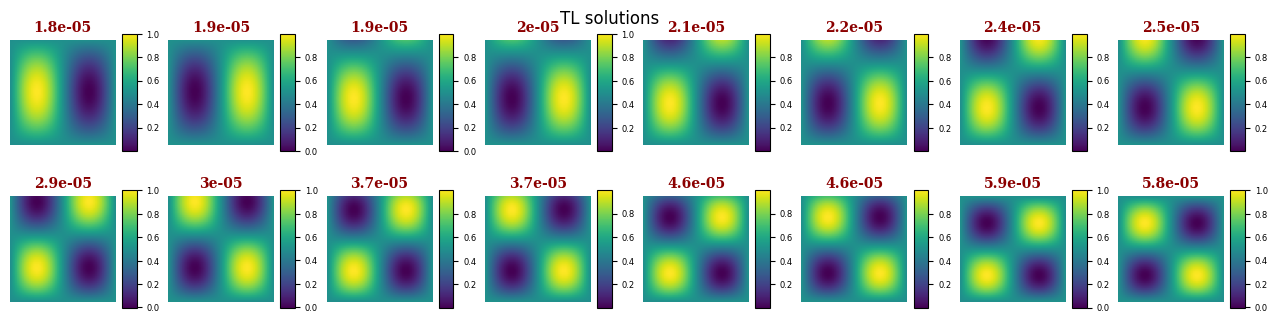

In [14]:
Images = []; rd_losses = []
for i, force in enumerate(Forcing_functions):
	W = compute_TLW(b, force, Minv, H_dict, x, t)
	image = compute_solution(H, W, I=61)
	rd_losses.append(after_loss(H_dict, W, force, b, x, t))
	Images.append(image)
print("Relative Erorr: ", relative_error(Images, truth_solution))
print("Mean Loss over all Heads: ", np.mean(rd_losses))

plot_solutions16(Images, "TL solutions", savfig = None, subtitle_list = [round(l, 6) for l in rd_losses])

## Transfer Learn Manufactured Solution 1

$$f(x, t) = Asin(2 \pi x) sin(k_2 \pi t)$$

with constant boundary condition fixed at 0.5.

In [24]:
u_min, u_max = -0.9, 1.0  # chebyshev interval
K = 30  # chebyshev order
M_nodes = 1000  # Gauss quadrature nodes
delta = 0.2  # parameter in R(u)
cheb_coeffs = rd_cheb_coeffs(u_min, u_max, K=K, M=M_nodes, delta=delta)

A_list = [0.25, 0.5, 0.75, 1]; k1 = 2; p = 20
k2_list = np.linspace(1, 2, 4); b = 0.5; r = 0.4
result_list = []; rd_loss2 = []
for A in tqdm(A_list):
	for k2 in k2_list:
		force = truth_decorator_trig(A, k1, k2)
		f0_values = force(x, t).detach().numpy()
		result = reaction_diffusion_solver(H_dict, Minv, cheb_coeffs, u_min, u_max, f0_values, b, r, H, p=p)
		result_list.append(result)
		rd_loss2.append(reaction_diffusion_loss(model, result['W'], r, delta, force, b0=b))

100%|██████████| 4/4 [00:02<00:00,  1.40it/s]


Average Reaction-Diffusion Loss:  0.00011487103749063769
Average Relative PDE loss:  0.03782597919576774
Average Relative BC loss:  7.534454841235963e-08


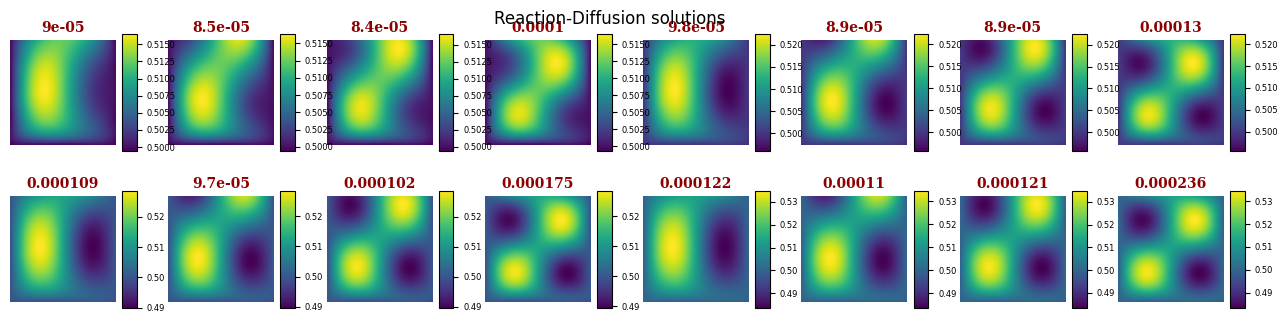

In [25]:
plot_solutions16([result['sol'] for result in result_list], 'Reaction-Diffusion solutions',
                  subtitle_list = [round(l['total_loss'], 6) for l in rd_loss2])
print("Average Reaction-Diffusion Loss: ", np.mean([l['total_loss'] for l in rd_loss2]))
print("Average Relative PDE loss: ", np.mean([l['relative_pde_loss'] for l in rd_loss2]))
print("Average Relative BC loss: ", np.mean([l['relative_bc_loss'] for l in rd_loss2]))

## Transfer Learn Manufactured Solution 2

$$u(x, t) = Ax(x-1)sin(k t) + b$$

with constant boundary condition fixed at 0.5.

In [26]:
p = 12  # perturbaion order
u_min, u_max = -0.9, 1.0  # chebyshev interval
K = 30  # chebyshev order
M_nodes = 1000  # Gauss quadrature nodes
delta = 0.2  # parameter in R(u)
cheb_coeffs = rd_cheb_coeffs(u_min, u_max, K=K, M=M_nodes, delta=delta)

In [27]:
def function_decorator3(A, k, b=0):
    def func(x, t):
        return A*x*(x-1)*torch.sin(k*t) + b
    return func

def forcing_decorator3(A, k, r, b=0):
    func = function_decorator3(A, k, b)
    def force(x, t):
        u = func(x, t)
        return A*k*x*(x-1)*torch.cos(k*t) - 2*A*torch.sin(k*t) - r*(u/(u+1)-delta*u)
    return force
        

In [28]:
A = 2; k =2*np.pi + 1; r = 0.5
exact_func = function_decorator3(A, k, b=0.5)
forcing = forcing_decorator3(A, k, r, b=0.5)
exact_values = exact_func(x,t).detach().numpy().reshape(60, -1)
forcing_values = forcing(x, t).detach().numpy().reshape(60, -1)

Text(0.5, 0.9, 'Example Solution and Corresponding Forcing Function')

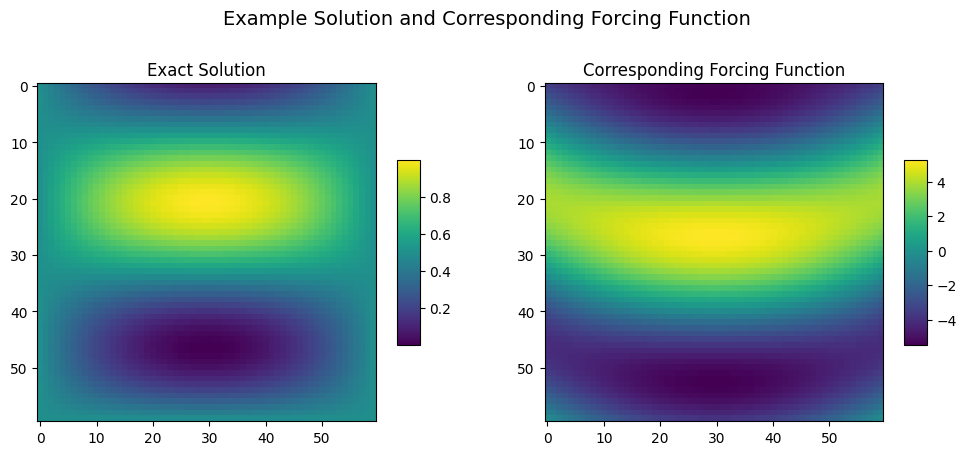

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im0 = ax[0].imshow((exact_values.T)[::-1])
im1 = ax[1].imshow((forcing_values.T)[::-1])
cbar0 = fig.colorbar(im0, ax=ax[0], shrink=0.4, aspect=8)
cbar0.ax.tick_params(labelsize=10)
cbar1 = fig.colorbar(im1, ax=ax[1], shrink=0.4, aspect=8)
cbar1.ax.tick_params(labelsize=10)
ax[0].set_title("Exact Solution")
ax[1].set_title("Corresponding Forcing Function")
fig.suptitle("Example Solution and Corresponding Forcing Function", fontsize=14, y=0.9)

In [37]:
x, t, interior_tensor = generate_interior_tensor(I=60, require_grad = False)
x_boundary, t_boundary, boundary_tensor = generate_boundary_tensor(B=200, require_grad=False, method='equally-spaced')

In [38]:
p = 20; r = 0.5
A_list = [1, 2]; K_list = np.linspace(np.pi, 4*np.pi, 4);  B_list = np.linspace(0.2, 0.8, 4)
manufactured_list = []
perturbation_list = []
rd_loss_list = []
mse_list = []

In [39]:
total_time = 0
for A in A_list:
    for k in K_list:
        for b in B_list:
            # Compute the TL solutions
            force = forcing_decorator3(A, k, r, b=b)
            f0_values = force(x, t).detach().numpy()
            s = time.time()
            result = reaction_diffusion_solver(H_dict, Minv, cheb_coeffs, u_min, u_max, f0_values, b, r, H, p=p)
            e = time.time()
            total_time += (e - s)
            perturbation_list.append(result['sol'])
            # Compute the truth solutions
            truth_func = function_decorator3(A, k, b=b)
            truth = truth_func(X_grid[:,0], X_grid[:, 1]).reshape(61, -1).detach().numpy()
            manufactured_list.append(truth)
            # Compute MSE for each one
            mse_list.append(((truth - result['sol'])**2).mean())
            # Compute the loss
            rd_loss_list.append(reaction_diffusion_loss(model, result['W'], r, delta, force, b0=b))

print("Average time per solve: ", total_time / len(perturbation_list))

Average time per solve:  0.09842030704021454


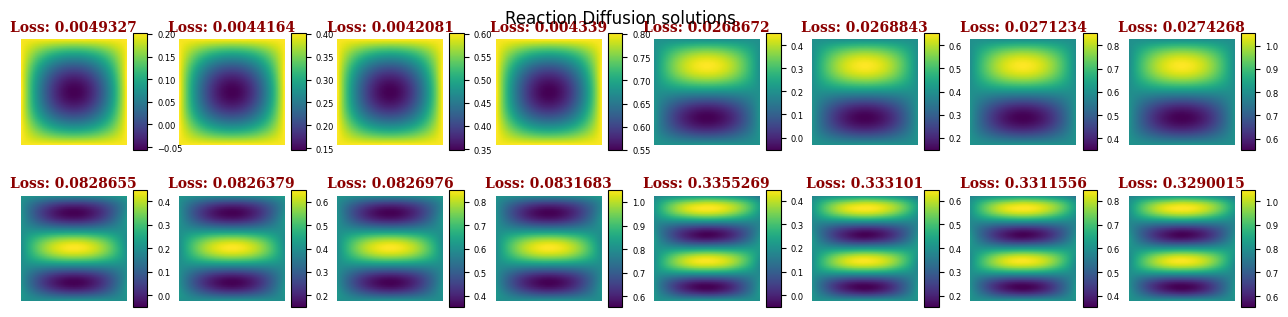

In [40]:
plot_solutions16(perturbation_list, 'Reaction Diffusion solutions', 
                subtitle_list = ["Loss: " + str(round(l['total_loss'], 7)) for l in rd_loss_list]);

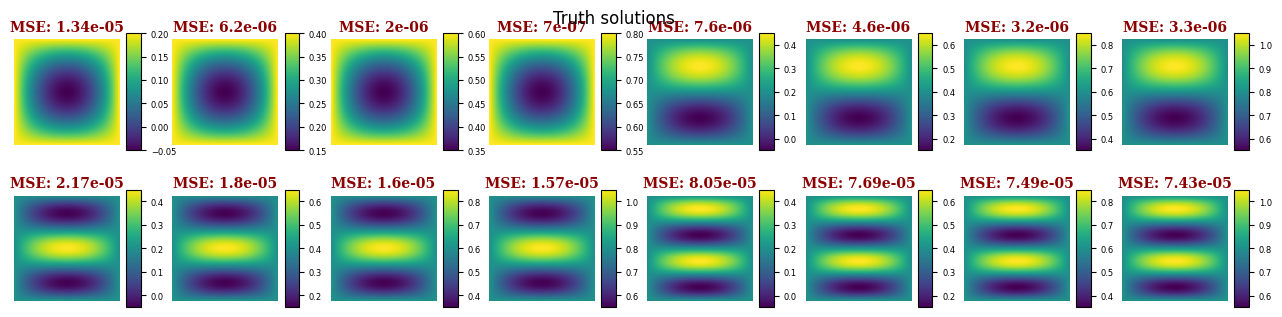

In [41]:
plot_solutions16(manufactured_list, 'Truth solutions', subtitle_list = ["MSE: " + str(round(mse, 7)) for mse in mse_list]);

In [42]:
print("Average Reaction Diffusion's Loss: ", np.mean([l['total_loss'] for l in rd_loss_list]))
print("Average Relative PDE residual diff: ", np.mean([l['relative_pde_loss'] for l in rd_loss_list]))
print("Average Relative BC loss: ", np.mean([l['relative_bc_loss'] for l in rd_loss_list]))
relative_error = abs(np.array(perturbation_list) - np.array(manufactured_list)).mean()/abs(np.array(manufactured_list)).mean()
print("Mean relative error: ", relative_error)
print("MSE loss: ", np.mean(mse_list))

Average Reaction Diffusion's Loss:  0.28199484482528997
Average Relative PDE residual diff:  0.10078118828457247
Average Relative BC loss:  0.0002468150855969258
Mean relative error:  0.011577767203927197
MSE loss:  7.120280418752698e-05


In [43]:
indices = [-1]
TL_solution = np.array(perturbation_list)[indices]
truth_solution = np.array(manufactured_list)[indices]

difference = (TL_solution - truth_solution)**2

In [44]:
import warnings
warnings.filterwarnings('ignore')

def float_to_scientific_notation(num):
    result = "{:.1e}".format(num)
    result2 = result[:-2]
    result2 += result[-1]
    return result2

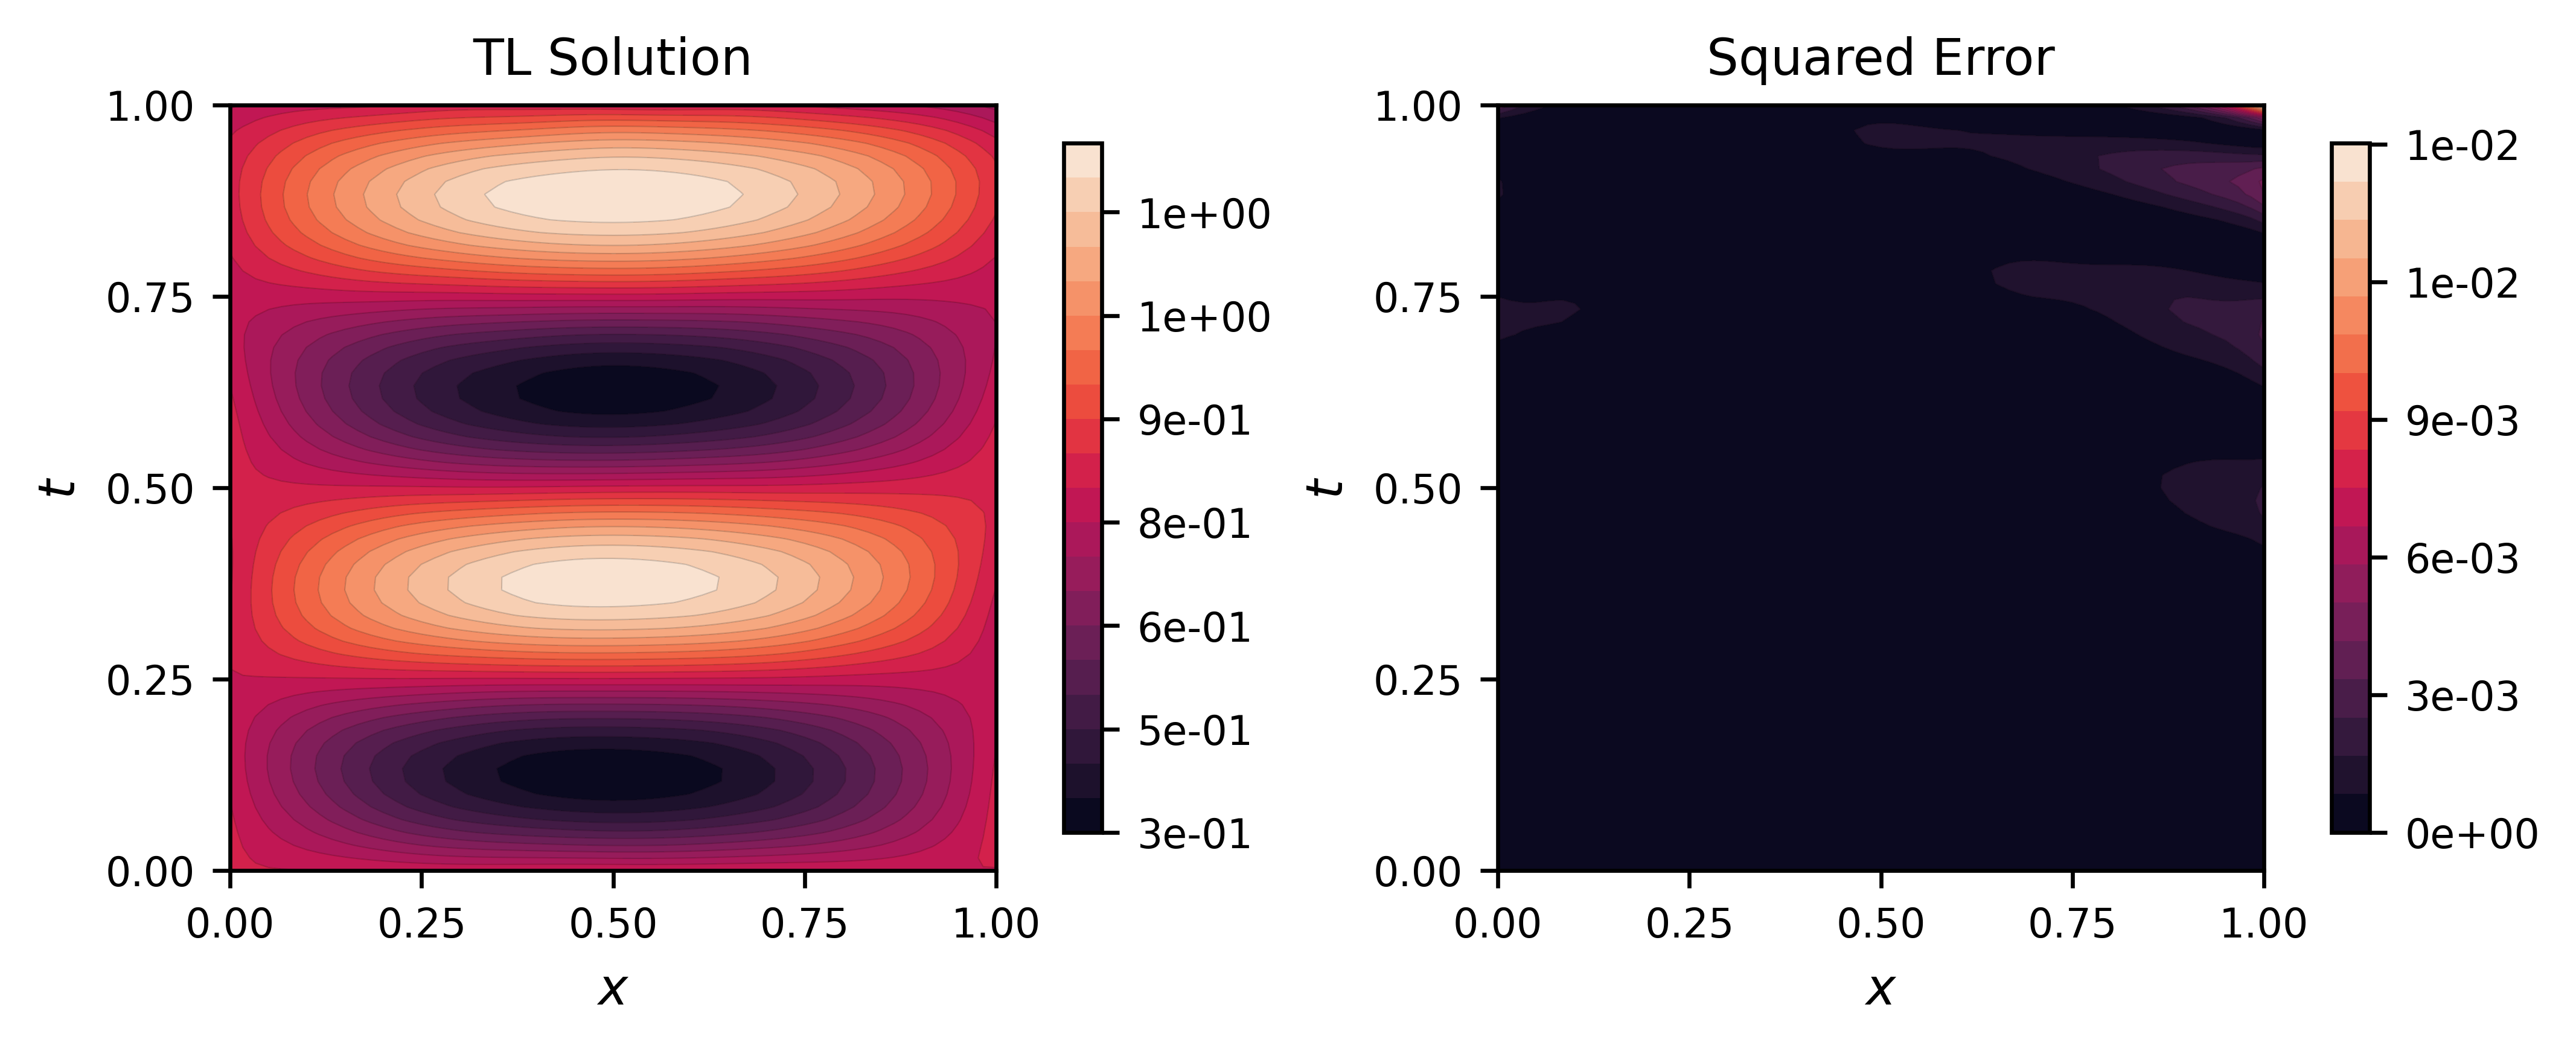

In [45]:
try:
    import seaborn as sns
    cmap = sns.color_palette("rocket", as_cmap=True)
except Exception:
    cmap = "magma"

def sci0(x, pos=None):
    return f"{x:.0e}"

sol  = TL_solution[0] if isinstance(TL_solution, (list, tuple)) else TL_solution
diff = difference[0]  if isinstance(difference,  (list, tuple)) else difference
sol  = np.squeeze(sol)
diff = np.squeeze(diff)

if sol.ndim != 2 or diff.ndim != 2:
    raise ValueError(f"Expected 2D arrays after squeeze, got sol.ndim={sol.ndim}, diff.ndim={diff.ndim}")

ny, nx = sol.shape
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(1, 2, figsize=(7.0, 3.8), constrained_layout=True, dpi=600)

levels_sol  = 20
levels_diff = 20

cf1 = ax[0].contourf(X, Y, sol, levels=levels_sol, cmap=cmap)

ax[0].contour(X, Y, sol, levels=levels_sol, colors="k", linewidths=0.25, alpha=0.18)

ax[0].set_xlabel(r"$x$", fontsize=10)
ax[0].set_ylabel(r"$t$", fontsize=10)
ax[0].set_aspect("equal")
ax[0].set_xticks(np.linspace(0, 1, 5))
ax[0].set_yticks(np.linspace(0, 1, 5))
ax[0].set_title("TL Solution", fontsize=10)
ax[0].tick_params(labelsize=8)

cbar1 = fig.colorbar(
    cf1, ax=ax[0],
    shrink=0.75,
    fraction=0.05,
    pad=0.03,
    aspect=18
)
cbar1.ax.tick_params(labelsize=8)
cbar1.formatter = FuncFormatter(sci0)
cbar1.update_ticks()

vmin, vmax = 0.0, diff.max()
cf2 = ax[1].contourf(X, Y, diff, levels=levels_diff, cmap=cmap, vmin=vmin, vmax=vmax)
ax[1].contour(X, Y, diff, levels=levels_diff, colors="k", linewidths=0.25, alpha=0.18)

ax[1].set_xlabel(r"$x$", fontsize=10)
ax[1].set_ylabel(r"$t$", fontsize=10)
ax[1].set_aspect("equal")
ax[1].set_xticks(np.linspace(0, 1, 5))
ax[1].set_yticks(np.linspace(0, 1, 5))
ax[1].set_title("Squared Error", fontsize=10)
ax[1].tick_params(labelsize=8)

ticks = np.linspace(vmin, vmax, 6)
cbar2 = fig.colorbar(
    cf2, ax=ax[1],
    ticks=ticks,
    shrink=0.75,
    fraction=0.05,
    pad=0.03,
    aspect=18
)
cbar2.ax.tick_params(labelsize=8)
cbar2.formatter = FuncFormatter(sci0)
cbar2.update_ticks()

plt.show()